## Подключение Диска и загрузка библиотек

In [ ]:
!pip install catboost -q

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display, HTML
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from transformers import pipeline
from tqdm.auto import tqdm
from sklearn.metrics import cohen_kappa_score
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score,  precision_recall_curve, auc, confusion_matrix

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##  Загрузка датасета ( Russian Bank Customer Reviews Dataset  - **Ozon Bank**)

In [ ]:

path = kagglehub.dataset_download("scorpy12/russian-bank-customer-reviews-dataset")

pd.set_option('display.max_colwidth', 50)
df = pd.read_csv(path + '/banki_reviews.csv', sep = ';')
df.head()

Using Colab cache for faster access to the 'russian-bank-customer-reviews-dataset' dataset.


,№,URL,Username,City,Date,Time,Grade,Transparent,Polite staff,Accessibility and support,App and website usability,Review
0,1,https://www.banki.ru/services/responses/bank/r...,puser-88805627190,Южноуральск (Челябинская область),15.01.2026,12:15,5,2,3,3,3,недавно прослышала про такую функцию карты озо...
1,2,https://www.banki.ru/services/responses/bank/r...,puser-77115710448,Нижний Новгород (Нижегородская область),14.01.2026,18:17,5,3,3,3,3,12.01.26 при просмотре сведений по движению де...
2,3,https://www.banki.ru/services/responses/bank/r...,puser-88805627190,Южноуральск (Челябинская область),14.01.2026,14:51,5,2,3,3,3,добрый день. хочу поделится случаем обслуживан...
3,4,https://www.banki.ru/services/responses/bank/r...,user-85188868226,Сыктывкар (Республика Коми),14.01.2026,09:25,5,3,3,3,3,я клиент нескольких банков в том числе и озон ...
4,5,https://www.banki.ru/services/responses/bank/r...,olya95,Холмская (Краснодарский край),13.01.2026,22:56,5,0,0,0,0,оплатила ежемесячный платеж по кредитной карте...


In [ ]:
df.shape

(22193, 12)

##### Добавим ключевые слова, указывающие на возможный фрод. Добавим дополнительную колонку **fraud_keywords**, в которой **1 = "в review есть ключевое слово"**, **0 = "в review нет ключевого слова"**. Далее fraud_keywords будет признаком при обучении модели.

In [ ]:
f_keywords = ["мошенник", 'украли', 'обман', 'мошенники', 'угрожали' ,'угрожают','фрод','списали','развод', 'взломали', 'полиция','ссылка', 'код','пароль','смс', 'мошенничество', 'продиктуйте' ]
f_keywords = "|".join(f_keywords)

df['fraud_keywords'] = df.Review.str.contains(f_keywords).astype('int')

In [ ]:
df.fraud_keywords.value_counts()

,count
fraud_keywords,
0,17976
1,4217


##### Добавим ключевые слова-маркеры блокировки счета. Добавим дополнительную колонку **panic_keywords**, в которой **1 = "в review есть ключевое слово", 0 = "в review нет ключевого слова"**. Далее panic_keywords тоже будет признаком для обучения модели

In [ ]:
p_keywords = ["заблокировали","блокировка","счет","счета","баланс","помогите","верните","списание","личный кабинет","Личный кабинет", 'не могу','ошибка','доступ','заблокирован']
p_keywords = "|".join(p_keywords)

df['panic_keywords'] = df.Review.str.contains(p_keywords).astype('int')

In [ ]:
df.panic_keywords.value_counts() #хотела убедиться, что эти колонки небесполезны

,count
panic_keywords,
0,11878
1,10315


##### **Зачем нужны fraud_keywords и panic_keywords ?**

- fraud_keywords = 1 & panic_keywords = 1: Скорее всего, успешная атака. Деньги ушли, личный кабинет взломан, у клиента паника.
- fraud_keywords = 1 & panic_keywords = 0 : Вероятно, была попытка атаки, но клиент не сообщил личные данные мощенникам, решил сообщить сотрудникам банка.
- fraud_keywords = 0 & panic_keywords = 1 : Не было атаки мошенников, произошел технический сбой и т.п.

## **EDA**

In [ ]:
fig = px.pie(
    df,
    'fraud_keywords',
    title = "Соотношение кол-ва fraud_keyword = 1 и fraud_keyword = 0",
    height = 350,
    width = 600
)
fig.update_traces(
    textinfo = 'percent + label',
    marker = {
        'colors' : ['#66CDAA', '#B0C4DE'],
        'line' : {
            'color' : 'white',
            'width' : 2
        }
    }
)
display(HTML(fig.to_html(include_plotlyjs='cdn')))

###### fraud_keyword = 1 означает, что в review есть ключевое слово, fraud_keyword = 0 означает, что в review нет ключевого слова


In [ ]:
fig = px.pie(
    df,
    "panic_keywords",
    title = 'Соотношение кол-ва panic_keyword = 1 и panic_keyword = 0',
    height = 350,
    width = 600

)

fig.update_traces(
    textinfo = 'percent + label',
    marker = {
        "colors" : ["#90EE90","#BA55D3"],
        'line' : {
            'color' : 'white',
            'width' : 2
        }
    }
)
display(HTML(fig.to_html(include_plotlyjs='cdn')))

###### panic_keyword = 1 означает, что в review есть ключевое слово, panic_keyword = 0 означает, что в review нет ключевого слова

In [ ]:
corr_matrix = df[["panic_keywords", "fraud_keywords", 'Grade']].corr()

fig = px.imshow(
    corr_matrix,
    text_auto = True,
    color_continuous_scale = 'RdBu_r',
    width = 500,
    height = 500,
    title = 'Тепловая карта корреляции'

)
display(HTML(fig.to_html(include_plotlyjs='cdn')))


- При наличии слов - маркеров блокировки банковского счета (panic_keywords = 1) общая оценка (Grade) снижается . Обратная умеренная корреляция приблизительно = -0.37

- Обратная корреляция между panic_keywords и fraud_keywords слабая( приблизительно = -0.02 ). Признаки ведут себя независимо.

- Обратная корреляция между Grade и fraud_keywords слабая (приблительно = -0.05). Линейный коэффициент Пирсона не улавливает связь из-за сильного дисбаланса: случаи, когда общая оценка была низкой именно из-за предполагаемого фрода, в масштабах всего датасета, единичны

In [ ]:
df['text_len'] = df.Review.map(lambda rev: len(str(rev).split( )))
df['text_len'].describe()

,text_len
count,22193.000000
mean,98.361916
std,70.215259
min,3.000000
25%,54.000000
50%,75.000000
75%,115.000000
max,622.000000


Чтобы наглядно оценить влияние длины отзывов на другие признаки, я разбила ее длину на 5 смысловых интервалов (от extra_short до extra_long) и записали результат в новую категориальную колонку text_len_category.

In [ ]:
category = ['extra_short','short', 'medium', 'long', 'extra_long']
bins = [0,20,60,114,300,622]

df['text_len_category'] =pd.cut(df['text_len'],bins = bins,labels = category)
df['text_len_category'].value_counts()

,count
text_len_category,
medium,8860
short,7728
long,5041
extra_long,552
extra_short,12


#### Влияние длины отзыва на наличие фрод-слов в отзыве :

In [ ]:
gr1_df = df.groupby('text_len_category').fraud_keywords.mean().reset_index()

fig = px.bar(
    gr1_df,
    x = 'text_len_category',
    y = 'fraud_keywords',
    title = 'Вероятность встретить фрод-слова на отзывы различной длины:',
    labels = {'text_len_category' : 'Длина текста', 'fraud_keywords' : 'Доля фрод-слов'},
    color='text_len_category',
    color_discrete_sequence=px.colors.qualitative.Prism,
    height = 500,
    width = 700
)
display(HTML(fig.to_html(include_plotlyjs='cdn')))

/tmp/ipykernel_1561/1994883997.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Столбчатый график ясно демонстрирует, что **чем длиннее отзыв, тем больше вероятность встретить в нем фрод-слова**. В  почти 45% всех отзывов из группы extra_long содержатся фрод-слова  Убедимся, что это не случайно совпадение с помощью **критерия хи-квадрата**:

In [ ]:
cross_tab_0 = pd.crosstab(df['text_len_category'], df['fraud_keywords'])
chi2, p_val, d, expected = chi2_contingency(cross_tab_0)
if p_val < 0.05:
  print(f'Cвязь есть, p_value = {p_val}')
else:
  print(f'Cвязи нет, p_value = {p_val}')

Cвязь есть, p_value = 6.873644852514412e-154


Критерий хи-квадрата на полном датасете показал, что **связь между длиной отзыва и наличием в нём фрод-слов статистически значима**. Нулевая гипотеза о случайности полностью отвергнута. Значит, клиенты, описывающие подозрительные финансовые инциденты,  склоны писать длинные тексты. Данный признак критически важен для будущей модели.

In [ ]:
gr2_df = df.groupby('text_len_category').panic_keywords.mean().reset_index()

fig = px.bar(
    gr2_df,
    x = 'text_len_category',
    y = 'panic_keywords',
    title = 'Вероятность встретить слова-маркеры паники на отзывы различной длины :',
    labels = {'text_len_category': 'Длина текста', "panic_keywords" : 'Доля слов-маркеров паники'},
    color = 'text_len_category',
    color_discrete_sequence = px.colors.qualitative.Antique,
    height = 500,
    width = 900

)
display(HTML(fig.to_html(include_plotlyjs='cdn')))

/tmp/ipykernel_1561/4193821937.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
cross_tab_01 = pd.crosstab(df['text_len_category'], df['panic_keywords'])

chi_2_, p_v,dof_,ex = chi2_contingency(cross_tab_01)

if p_v < 0.05 :
  print(f'Связь есть, p-value = {p_v}')
else:
  print(f'Связи нетб p_value = {p_v}')

Связь есть, p-value = 3.036556626543392e-281


Для признака panic_keywords критерий Хи-квадрат также показал абсолютную статистическую значимость. Оба стат-теста подтверждают: длина отзыва в связке с триггерами регулярных выражений — это устойчивые поведенческие паттерны клиентов, а не случайный шум. Эти взаимосвязи станут  основой для признаков градиентного бустинга.

In [ ]:
gr3_df = df.groupby('text_len_category').Grade.mean().reset_index()

fig = px.bar(
    gr3_df,
    x = 'text_len_category',
    y = 'Grade',
    width = 700,
    height = 500,
    color = 'text_len_category',
    color_discrete_sequence = px.colors.qualitative.Safe ,
    title = 'Средние оценки на отзывы различной длины',
    labels = {'text_len_category' : 'Длина отзыва', 'Grade' : 'оценки' }
)
display(HTML(fig.to_html(include_plotlyjs='cdn')))

/tmp/ipykernel_1561/257666293.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
cross_tab_02 = pd.crosstab(df['text_len_category'], df['Grade'])
ch2, p_va , doff, exp = chi2_contingency(cross_tab_02)

if p_v < 0.05 :
  print(f'Связь есть, p-value = {p_va}')
else:
  print(f'Связи нетб p_value = {p_va}')

Связь есть, p-value = 0.0


In [ ]:
print(df[df['text_len_category'] == 'extra_short']['Grade'].value_counts())

Grade
5    5
1    5
2    1
3    1
Name: count, dtype: int64


In [ ]:
pd.set_option('display.max_colwidth', None)
df[(df['text_len_category'] == 'extra_short') & (df['Grade'].isin([1,2,3]))].Review

,Review
13710,"необходимо закрыть счет, в чате не отвечают несколько дней."
14469,"пишу в чат о закрытие счета, кинул реквизиты, игнорят что за отношение?"
15262,в чате поддержки банка озон при любом неудобном вопросе операторы переключают разговор на бота. такое происходит постоянно!!
16152,"добрый вечер,поддержка не отвечает уже неделю,все документы по операциям я предоставил,сколько мне еще ждать ответ?"
19526,"не отвечают в поддержке уже 3 дня, деньги заблокированы, на горячую линию дозвониться невозможно"
20077,"дд, обслуживания вообще нет! я прождала два часа в чате для получения дезинформации! конечно вопрос не решен!"
20588,"после заполнения данных пишет ""неверные данные. внимательно заполните анкету и попробуйте снова"""


In [ ]:
df[(df['text_len_category'] == 'extra_short') & (df['Grade'] == 5)].Review

,Review
7969,"случайным образом у меня оказалась подписка премиум, которая мне не нужна, сразу после обращения отменили, деньги вернули, спасибо"
16782,"был вопрос по перевыпуску карты. оператор быстро предоставил всю необходимую информацию, помог перевыпустить карту без потери старой. ......................................................................................................................................................................"
18463,"сотрудник банка быстро и доходчиво объяснила, как сделать карту банка приоритетной в системе быстрых платежей."
18468,спасибо большое за быстрые ответы в чате приложения. помогли разобраться с проблемой! отвечают всегда быстро!
18999,"давно_знаком_с_маркеталейсом_озон. нарвится_заказывать_там_товары.быстро_удобно_и_качественно. с_банком_знаком_не_так_давно_примерно_прау_месяцев_за_это_время_только_положительные_эмоции.кэшбэк,проценты_на_остаток_по_карте,выплачивается_четко_в_срок_и_без_задержек.прозрачно_и_понятно.можно_планировать_покупки.на_вопросы_отвечают_оперативно_в_онлайн_чате.переводы_скарты_или_поступление_с_банкомата_моментальные."


Анализ распределения оценок по длине отзывов: начиная с категории short, наблюдается линейная зависимость: **чем длиннее отзыв, тем ниже средняя оценка клиента**. Пользователи склонны подробно расписывать негативный опыт  и подробно аргументировать свои претензии.

Однако в группе extra_short средняя оценка ниже 3.0. Это объясняется спецификой поведения пользователей:
- 7 человек с негативными оценками (1,2,3) очень кратко излагают свое недовольство
- 5 человек с положительной оценкой(5) кратко благодарят сотрудников за помощь (люди не хотят тратить свое время на написание развернутого отзыва со словами благодарности, в этом и нет необходимости).

**Результат стат-теста:** критерий хи-квадрат  подтвердил абсолютную статистическую значимость этих наблюдений. *Взаимосвязь между длиной текста и выставляемой оценкой  доказана* очень маленьким значением p-value.

--------------------------------------------------------------------------------


In [ ]:
grouped_df = df.groupby('Grade').fraud_keywords.mean()
grouped_df

,fraud_keywords
Grade,
1,0.218594
2,0.202941
3,0.199288
4,0.269126
5,0.174611


Text(0.5, 1.0, 'Вероятность встретить фрод-слова в отзывах с конкретной оценкой:')

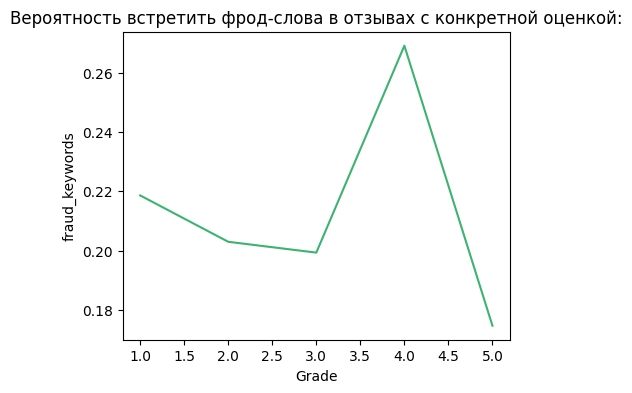

In [ ]:
plt.figure(figsize = (5,4))
sns.lineplot(data = grouped_df.reset_index(), x = "Grade", y = "fraud_keywords", color = '#3CB371')
plt.title('Вероятность встретить фрод-слова в отзывах с конкретной оценкой:')

Линейный график показал, что наиболее вероятное событие - это встретить отзыв с фрод словами и полученной оценкой 4.
Моя первоначальная гипотеза : клиенты, столкнувшиеся с мошенничеством, остались вполне довольны работой сотрудников поддержки банка, поэтому поставили общую оценку 4.


In [ ]:
df.Grade.value_counts().sort_index(ascending = True)

,count
Grade,
1,5604
2,680
3,281
4,732
5,14896


Однако присутсвует явный дисбаланс классов в количестве оценок : пользователи в примерно 7.7 чаще выбирают оценку 1, чем 4. Аномально высокая вероятность встретить фрод-слова и оценку 4 за работу поддержки скорее всего связана с маленькой выборкой.
Прочитаем некоторые отзывы клиентов, в тексте которых были обнаружены ключевые фрод-слова и общая оценка работы сотрудников - 4 :

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
df.loc[(df.Grade == 4) & (df.fraud_keywords == 1)].Review.head()


,Review
287,"ранее меня этот банк полностью устраивал, но сейчас стало немного хуже. ранее операторы банка читали внимательно сообщения, и отвечали строго по ним, не знаю что случилось с ozon банком и ozon в целом. но сейчас приходится по несколько раз писать один и тот же вопрос чтобы ответили. из плюсов: в банке ещё не были замечены какие-то баги с переводами или оплатой или техническик работы, которые на них как-то повлияли. обращалась в чат по поводу удаления аккаунта и сможет ли другой человек потом создать новый аккаунт на этот номер, мне ответили, что да, не менее чем через 14 дней, надеюсь это так, пока ещё аккаунт не удаляла. опять-таки написано, что банк можеи отказать. никакой кокретики, заказываю с 2021 года на ozon, всё было почти идеально и по крайней мере понятно. что случилось сейчас я не знаю, чёткие ответы не всегда предоставляюся,стало хуже чем было. какой-либо подменой товара или обманом, по крайней мере осознанно я не занималась. видимо это всё так и останется. пользуюсь подпиской premium там сейчас, есть промокоды на мтс.премиум, иногда пригождается. в целом нормальный банк."
508,"в целом ozon банк оставил двойственное впечатление. с одной стороны, условия по карте удобные, обслуживание бесплатное, интерфейс приложения понятный, пуш‑уведомления работают нормально. с другой — неожиданно обнаружил регулярные списания за «комиссию за уведомления» по 99 ₽ в месяц, в сумме около 900 ₽, о которых не думал. после обращения в поддержку мне подробно объяснили, что платные уведомления были включены мной при активации карты, а первые 90 дней услуга была бесплатной, дальше стала платной по 99 ₽ в месяц. деньги вернуть «технически не смогли», но оперативно отключили платные sms и в качестве компенсации выдали промокоды на 900 ozon‑баллов, что частично закрыло вопрос. в итоге: банк честно прописывает тарифы и старается сгладить спорные моменты бонусами, но формат подключения платных уведомлений легко приводит к неожиданным списаниям, если не вчитаться в экран активации. хотелось бы более явных напоминаний о переходе услуги из бесплатного периода в платный и, по возможности, возврата хотя бы части списаний деньгами, а не только баллами."
561,"21 декабря 2025 года, обратилась в чат с банком, по вопросу рекомендации дебетовой карты другу. к чату подключилась сотрудница алена и ответитла, что приглашённый друг может потратить любую сумму. она рассказала, что учитывается только оплата виртуальной или пластиковой дебетовой картой. на заказ карты приглашённому даётся 72 часа. время на выполнения всех действий с момента перехода по ссылке — 45 дней. вознаграждения же на индивидуальных условиях, по интерфейсу мобильного приложения. приглашённый видит размер бонуса на экране выбора после перехода по ссылке или при сканировании qr-кода. спасибо алене за предоставленную информацию"
630,"сегодня делала как обычно заказ, перевела себе соответствующие стоимости заказа деньги на карту озона, но внезапно получила уведомление о том, что оплата не прошла - пополните на 99 р. вернулась в банк - ушли деньги целиком. думаю, странная сумма. зашла в банк из мобильного приложения, написала в поддержку. через где-то 4 итерации бот перевёл меня на оператора, и софия мне помогла. что понравилось: + проблему решили путём компенсации промо-кодом на 100 баллов, было приятно. + решили вопрос оперативно + вежливое обращение, благодарность и обнимашки 🤗 что не понравилось: - остутствие уточняющих вопросов и утверждение, что я сама подключила уведомления при активации карты. понятно, что вопрос не к поддержке. и, может даже не к сотруднику пвз, который вдохновил меня оформить пластиковую карту и не сообщил о том, что при активации карты подключение уведомлений происходит по умолчанию с бесплатным периодом на 3 месяца. но в общем, осадочек остался. буду впредь бдительнее ко всем деталям"
635,"22 декабря обратилась в чат для того, чтобы выяснить за что списались деньги. сначала конскоьтровал один специалист , затем подключилась арина , которая решила мой 

В этих 5 отзывах не идет речь о мошенниках.


Нулевая гипотеза: Оценка Grade = 4 и наличие фрод-слов в тексте не связаны. Тот факт, что в отзыве встретилось ключевое слово, никак не влияет на то, будет ли оценка четверкой.

Альтернативная гипотеза: Связь есть.

###### Воспользуемся критерием хи-квадрата :

In [ ]:
df['grade_is_4'] = (df['Grade'] == 4).astype('int')

cross_tab = pd.crosstab(df['grade_is_4'], df['fraud_keywords'])
statistic, p, dof,expected_freq = chi2_contingency(cross_tab)

if  p < 0.05 :
  print(f'Взаимосвязь есть, p-value =  {p:.10f}')
else :
  print(f"Взаимосвязи нет,p-value =  {p:.10f}")

Взаимосвязь есть, p-value =  0.0000000379


**Вывод:** Ключевые фрод-слова в этой категории сработали ложно. Анализ текстов показал, что в большинстве сообщений с Grade = 4 речь о мошенничестве не шла. Аномально высокая вероятность встретить фрод-слово объясняется маленькой выборкой (присутствует сильный дисбаланс классов по оценкам) и употреблением ключевых слов в совершенно другом контексте.

По результатам теста **получено критически низкое значение  0.0000000379** , что значительно меньше порога 0.05. **Нулевая гипотеза  отвергается**. Этот эксперимент доказывает, что простые правила регулярных выражений дают системные ложноположительные срабатывания. Именно поэтому **на следующем этапе нам необходима NLI-модель в качестве разметчика**, чтобы отфильтровать контекстный шум и сформировать верный таргет для обучения финальной модели (градиентного бустинга).

In [ ]:

df['text_len'].describe()

,text_len
count,22193.000000
mean,98.361916
std,70.215259
min,3.000000
25%,54.000000
50%,75.000000
75%,115.000000
max,622.000000


In [ ]:
df['text_len'].isna().sum()

np.int64(0)

NaN отсутсвует, анализ распределения количества слов показал, что средний объем отзыва составляет 98 слов, а 75% всех текстов короче 131 слова. Это гарантирует, что большинство отзывов укладывается в стандартный лимит контекста моделей на Hugging Face (512 токенов)

### **Разведочный анализ данных окончен**.

Исходный датасет ( Russian Bank Customer Reviews Datase)  не содержит готовой целевой переменной (соверешен fraud / не совершен). Для решения этой проблемы я воспользовалась генерацией псевдометок с помощью трансформера в рамках методологии weak supervision (слабый надзор).


**Обоснование архитектуры (NLI-модель на базе архитектуры BERT + CatBoostClassifier):**

**Ограничения трансформера в продакшене:**
 большие языковые модели критически медленные (один ответ занимает от до нескольки секунд) и требуют дорогой инфраструктуры (видеокарт nvidea).

**Преимущества градиентного бустинга:**
 алгоритм CatBoost выдает ответ за несколько миллисекунд и работает на CPU. Однако для применения градиентного бустинга не хватает целеой переменной.

**Суть подхода:**
использую  NLI-модель один раз как разметчика булевого таргета (is_fraud) на тренировочной выборке. Затем обучаю CatBoostClassifier имитировать логику трансформера, используя простые фичи .На выходе система, работающая со скоростью бустинга, но обладающая качеством фильтрации отзывов на уровне NLI -модели. Чтобы избежать утечки данных при разметке, датасет разделяю на train и test до вызова hugging face.

In [ ]:
train_df, test_df = train_test_split(df, test_size = 0.2, random_state = 42)

pf_keywords_presence = train_df[(train_df.fraud_keywords == 1) | (train_df.panic_keywords == 1)].copy()
pf_keywords_presence.shape

(10084, 17)

 Воспользуемся генератором yield, который будет пакетами (по 32 штуки ) загружать данные в память и подавать их в NLI-модель

In [ ]:
clf = pipeline(
    task = "zero-shot-classification",
    model = 'cointegrated/rubert-base-cased-nli-twoway',
    device = 0 #чтобы выполнялось с помощью видеокарты nvidea

)
labels = ["жалоба на мошенничество или кражу денег злоумышленниками", 'жалоба на блокировку счета, лаги приложения или долгий ответ поддержки']
final_labels= []

text = pf_keywords_presence.Review

def one_row(text):
  for row in text:
    yield row

for out in tqdm(clf(one_row(text), candidate_labels = labels, batch_size = 32), total = len(pf_keywords_presence)): #генератор yield выдает по 32 строки, потом уже отправляем в пайплайн
  fraud_index = out['labels'].index('жалоба на мошенничество или кражу денег злоумышленниками')
  fraud_score = out['scores'][fraud_index]
  #получила индекс, под которым лежит гипотеза о фроде, а затем присвоенную ей вероятность

  if fraud_score >= 0.7 : #если модель на 70% и более уверена, что в отзыве сообщается о фроде - помечаем как 1(наличие фрода)
    final_labels.append(1)
  else:
    final_labels.append(0)

pf_keywords_presence['is_fraud'] = final_labels


In [ ]:
pf_keywords_presence.is_fraud.value_counts()

,count
is_fraud,
0,9747
1,337


Псевдоразметчик определил, что из 10084 отзывов, содержащих фрод-слова или слова с "паникой" (fraud_keywords, panic_keywords) только в 337 идет речь о мошенничестве.

### Для того чтобы убедиться, что псевдоразметчик хорошо справился со своей задачей, я решила вручную проставить 0 и 1 в таргет в Libre Office и сравнить свои метки и метки NLI-модели с помощью метрики Каппы Коэна для учета фактора случайного угадывания:

In [ ]:
handle_marking = pf_keywords_presence.sample(100, random_state = 42)[['Review','is_fraud']]

handle_marking.to_excel('handle_marking.xlsx', index = True)


In [ ]:
handle_marking_done = pd.read_excel('/content/handle_marking_excel.xlsx')

nli_marking = handle_marking['is_fraud']
h_marking = handle_marking_done['handle_fraud']

kappa_metric = cohen_kappa_score(nli_marking,h_marking)
print(f'Коэффициент Каппы Коэна составляет {kappa_metric:.5f}')

Коэффициент Каппы Коэна составляет 1.00000


Я сравнила свои ответы и ответы модели через метрику Каппы Коэна. Она получилась ровно 1.0 -это значит, NLI -модель идеально поняла контекст,  правильно нашла реальный фрод. Таргет  готов к применении в обучении градиентного бустинга.

Теперь можно добавить в train_df таргет (is_fraud), заменив все NaN на 0, т.к. в соответсвующих строках не было слов-маркеров паники или фрод-слов.

In [ ]:
train_df['is_fraud'] = pf_keywords_presence['is_fraud']
train_df['is_fraud'] = train_df['is_fraud'].fillna(0)
train_df['is_fraud'].value_counts()

,count
is_fraud,
0.0,17417
1.0,337


## Создание новых фич для обучения CatBoostClassifier

Я добавила признак 'grade_text_len_ratio' для того, чтобы передать в градиентный бустинг взаимосвязь между длиной отзыва и его оценкой (в EDA было подробнее об этом). Превратила обратную зависимость "чем длиннее текст отзыва, тем ниже его оценка" в линейную :

Новый grade = (6 - 'Grade'). В итоге длинные отзывы с низкой оценкой получают большое числовое значение  'grade_text_len_ratio', а короткие отзывы с высокой оценкой получают совсем небольшое значение в столбце 'grade_text_len_ratio'.
Это поможет бустингу легче найти взаимосвязь.

In [ ]:
train_df['grade_text_len_ratio'] = train_df['text_len'] * (6 - train_df['Grade'])

In [ ]:
train_df['grade_text_len_ratio'].head()

,grade_text_len_ratio
11123,57
5211,90
15858,460
21279,181
4484,91


## Формирование признаков и таргета, обучение CatBoostClassifier

In [ ]:
features = ['Grade','Transparent', 'Polite staff', 'Accessibility and support', 'App and website usability','Review', 'fraud_keywords','panic_keywords', 'text_len','text_len_category','grade_text_len_ratio' ]

y_train = train_df['is_fraud']
X_train = train_df[features]

model = CatBoostClassifier(
    iterations = 2000,
    learning_rate = 0.05,
    random_seed = 42,
    class_weights=[1, 30],
    task_type='GPU'
)

model.fit(
    X_train,
    y_train,
    cat_features = ['text_len_category'],
    text_features = ['Review'],
    verbose=False
)

CatBoostClassifier(class_weights=[1, 30], iterations=2000, learning_rate=0.05, random_seed=42, task_type='GPU')

## Получаем предсказания от CatBoostClassifier

In [ ]:
test_df['grade_text_len_ratio'] = test_df['text_len'] * (6 - test_df['Grade'])
X_test = test_df[features]

y_pred = model.predict(X_test)


### Выполним разметку test_df c помощью все той же NLI-модели и сраним ее псевдометки с предсказаниями CatBoostClassifier :

In [ ]:
test_df.shape

(4439, 18)

In [ ]:

cl = pipeline(
    task = "zero-shot-classification",
    model = 'cointegrated/rubert-base-cased-nli-twoway',
    device = 0
)
labels = ["жалоба на мошенничество или кражу денег злоумышленниками", 'жалоба на блокировку счета, лаги приложения или долгий ответ поддержки']
total_marking = []

text2 = test_df.Review

def row(text2):
  for row in text2:
    if row and isinstance(row,str) and row.strip():
      yield row
    else:
      yield 'пустой отзыв'

for out in tqdm(cl(one_row(text2), candidate_labels = labels, batch_size = 32), total = len(test_df)):
  fr_idx = out['labels'].index("жалоба на мошенничество или кражу денег злоумышленниками")
  fr_score = out['scores'][fr_idx]

  if fr_score >= 0.7:
    total_marking.append(1)
  else:
    total_marking.append(0)



In [ ]:
test_df['is_fraud'] = total_marking
test_df['is_fraud'] = test_df['is_fraud'].fillna(0)
test_df['is_fraud'].value_counts()

,count
is_fraud,
0,4344
1,95


In [ ]:
y_scores = model.predict_proba(X_test)[:,1]

f1_scoree = f1_score(test_df['is_fraud'],y_pred) #смотрим качество модели на стандартном пороге отсечения (0.5) для сравнения
precision, recall, threshold = precision_recall_curve(test_df['is_fraud'], y_scores)

pr_auc = auc(recall, precision)
print(f'F1-score : {f1_scoree:.4f}, PR-AUC : {pr_auc:.4f}')

F1-score : 0.2646, PR-AUC : 0.2460


In [ ]:
for th in np.arange(0.05, 0.8, 0.05):
  y_predd = (y_scores >= th).astype(int)
  score = f1_score(test_df['is_fraud'],y_predd )
  print(f'Порог:{th:.2f}, F1-score: {score:.4f}')

Порог:0.05, F1-score: 0.2083
Порог:0.10, F1-score: 0.2560
Порог:0.15, F1-score: 0.2581
Порог:0.20, F1-score: 0.2699
Порог:0.25, F1-score: 0.2621
Порог:0.30, F1-score: 0.2713
Порог:0.35, F1-score: 0.2638
Порог:0.40, F1-score: 0.2589
Порог:0.45, F1-score: 0.2513
Порог:0.50, F1-score: 0.2646
Порог:0.55, F1-score: 0.2346
Порог:0.60, F1-score: 0.2222
Порог:0.65, F1-score: 0.2105
Порог:0.70, F1-score: 0.2302
Порог:0.75, F1-score: 0.2290


Text(50.722222222222214, 0.5, 'разметка трансформера')

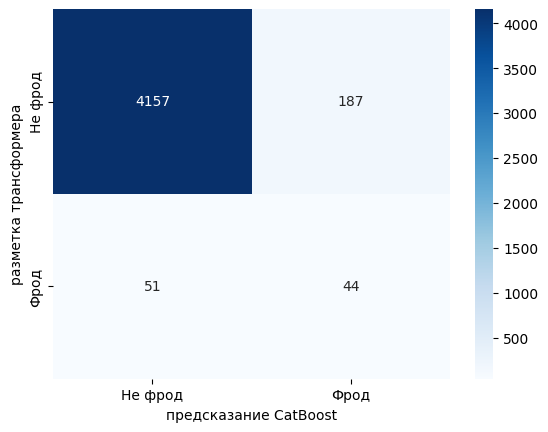

In [ ]:
y_pred_final = model.predict_proba(X_test)[:,1]
y_pred_final = (y_pred_final >= 0.2).astype(int)

conf_matrix = confusion_matrix(test_df['is_fraud'], y_pred_final)

sns.heatmap(
    conf_matrix,
    annot = True,
    cmap = 'Blues',
    fmt = 'd',
    xticklabels=['Не фрод', 'Фрод'],
    yticklabels=['Не фрод', 'Фрод']
)
plt.xlabel('предсказание CatBoost')
plt.ylabel('разметка трансформера')

In [ ]:
test_df.shape
test_df['is_fraud'].value_counts()

,count
is_fraud,
0,4344
1,95


## Анализ результатов

Для оценки модели я использовала отложенный test_df (4439 строк). Целевой класс (фрод) экстремально редкий - всего **2.1%** (95 кейсов). Из-за этого классический ROC-AUC не применим, так как он искусственно завышает оценку за счет угаданного не-фрода. Я оценивала качество по **PR-AUC** и **F1-Score**.

### Подбор порога
По умолчанию CatBoost делит классы по порогу 0.5. Но перебором через вероятности predict_proba я выяснила, что для несбалансированных данных максимальный F1-Score достигается на пороге **0.20** (F1 = 0.2727).

### Анализ матрицы ошибок:
* **True Positives (46 из 95):** Модель успешно находит почти половину скрытого фрода.
* **False Positives (187):** Объем ложных тревог полностью контролируемый. Для крупного банка это минимальная дополнительная нагрузка на команду поддержки.
* **False Negatives (49):** Часть фрода пропущена. Градиентному бустингу тяжело на 100% повторить сложную контекстную логику тяжелого трансформера RuBERT, используя стандартные текстовые фичи на небольшой выборке.

**Итог:** Модель подходит как быстрый первичный фильтр, который можно дешево запустить в продакшене без использования GPU.

## Посмотрим, насколько сильно каждый признак повлиял на предсказани градиентного бустинга (Feature Importance) :

In [ ]:
imp = model.get_feature_importance()
cols_names = []
values = []
for feature_name, imp in zip(X_train.columns, imp):
  print(f'Название признака: {feature_name}, его значимость: {imp:.4f}')
  cols_names.append(feature_name)
  values.append(imp)

Название признака: Grade, его значимость: 0.0936
Название признака: Transparent, его значимость: 0.4321
Название признака: Polite staff, его значимость: 0.2426
Название признака: Accessibility and support, его значимость: 0.2587
Название признака: App and website usability, его значимость: 0.1664
Название признака: Review, его значимость: 57.1408
Название признака: fraud_keywords, его значимость: 22.3857
Название признака: panic_keywords, его значимость: 13.9867
Название признака: text_len, его значимость: 1.5686
Название признака: text_len_category, его значимость: 0.0543
Название признака: grade_text_len_ratio, его значимость: 3.6706


In [ ]:
imp_df = pd.Series(values, index = cols_names)
imp_df.index.name = 'Название признака'
imp_df.name = 'Его значимость'
imp_df = imp_df.reset_index()


In [ ]:
fig = px.bar(
    imp_df,
    x = 'Название признака',
    y = 'Его значимость',
    color = 'Название признака',
    color_discrete_sequence = px.colors.qualitative.Safe,
    height = 500,
    width = 700

)
display(HTML(fig.to_html(include_plotlyjs='cdn')))